In [11]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pathlib
from datetime import datetime

from scipy.optimize import curve_fit
import natural_cubic_spline_stack_overflow_kopi as ncs # taken from stack overflow




In [12]:
population = pd.read_excel("Danmark_befolkningstall.xlsx", skiprows=2, usecols="B:CF")
population = population.T 
population.index.name = "Year"
population.columns = ["Population"]
population.head()


,Population
Year,
1769,797584
1787,841806
1801,929001
1834,1230964
1840,1289075


## Raw data

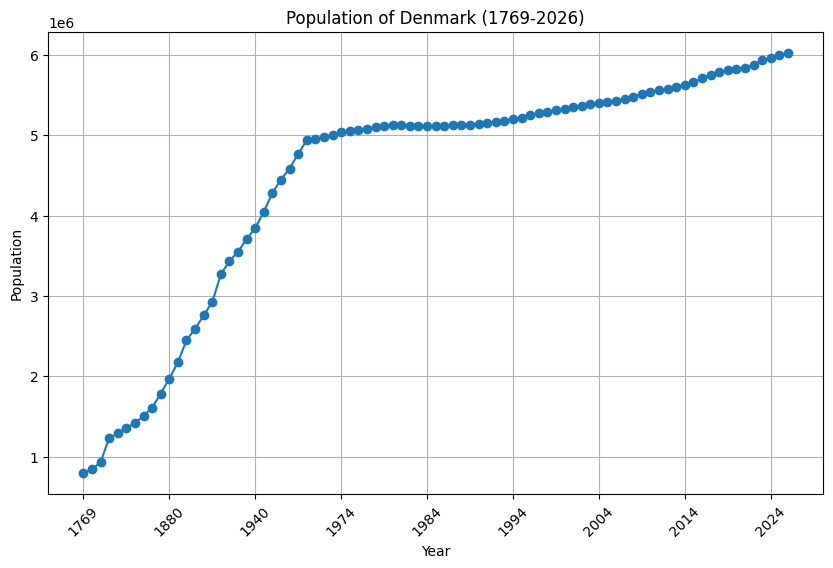

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(population.index, population["Population"], marker='o')
plt.title("Population of Denmark (1769-2026)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid()
# show only every 10th x-tick
xticks = population.index[::10]
plt.xticks(xticks, rotation=45)
plt.show()


In [14]:
years = population.index.to_numpy()
values = population["Population"].to_numpy()

print(type(values))

# Option A: with numpy.column_stack (recommended)
population_array = np.column_stack((years, values))

# Option B: with zip (keeps mixed dtypes)
# population_array = np.array(list(zip(years, values)))

print(population_array.shape)
print(population_array)

population_array = population_array[0:].astype(float)
print(type(population_array[0,0]))

<class 'numpy.ndarray'>
(83, 2)
[['1769' 797584]
 ['1787' 841806]
 ['1801' 929001]
 ['1834' 1230964]
 ['1840' 1289075]
 ['1845' 1356877]
 ['1850' 1414648]
 ['1855' 1507222]
 ['1860' 1608362]
 ['1870' 1784741]
 ['1880' 1969039]
 ['1890' 2172380]
 ['1901' 2449540]
 ['1906' 2588919]
 ['1911' 2757076]
 ['1916' 2921362]
 ['1921' 3267831]
 ['1925' 3434555]
 ['1930' 3550656]
 ['1935' 3706349]
 ['1940' 3844312]
 ['1945' 4045232]
 ['1950' 4281275]
 ['1955' 4448401]
 ['1960' 4585256]
 ['1965' 4767597]
 ['1970' 4937579]
 ['1971' 4950598]
 ['1972' 4975653]
 ['1973' 5007538]
 ['1974' 5036184]
 ['1975' 5054410]
 ['1976' 5065313]
 ['1977' 5079879]
 ['1978' 5096959]
 ['1979' 5111537]
 ['1980' 5122065]
 ['1981' 5123989]
 ['1982' 5119155]
 ['1983' 5116464]
 ['1984' 5112130]
 ['1985' 5111108]
 ['1986' 5116273]
 ['1987' 5124794]
 ['1988' 5129254]
 ['1989' 5129778]
 ['1990' 5135409]
 ['1991' 5146469]
 ['1992' 5162126]
 ['1993' 5180614]
 ['1994' 5196642]
 ['1995' 5215718]
 ['1996' 5251027]
 ['1997' 5275121]

## Logistic curve

In [15]:
predictor_years = np.arange(1600, 2101)


In [16]:
def logistic(x:np.ndarray,ti:float,tau:float,C0:float,C1:float) -> np.ndarray:
    """
    General logistic function.
    Arguments:
    - x: np.ndarray of observation points (time)
    - ti: inflection time
    - tau: transition time coefficient
    - C0: start value
    - C1: end value

    Returns:
    - np.ndarray with len(x) number of points
    """
    return (C1 - C0)/(1 + np.exp(-(x - ti) / tau)) + C0

The optimal choice of parameters for the logistic function, given the sample data, is [1.92833721e+03 3.99329280e+01 7.14744227e+05 6.22880694e+06] (ti, tau, C0, C1).


<Figure size 640x480 with 0 Axes>

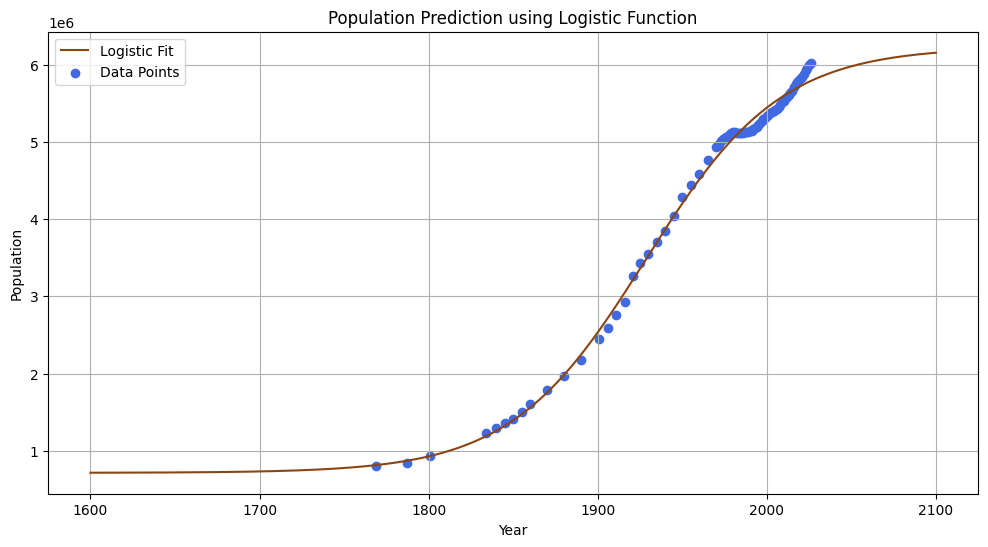

In [17]:
plt.clf()
inputs = population_array[:, 0]  # years
output = population_array[:, 1]  # population
pred_inputs = predictor_years

popt, pcov = curve_fit(logistic, inputs, output, p0=[1930, 40, 7e5, 6e6])
pred_outputs = logistic(pred_inputs, *popt)
print(f'The optimal choice of parameters for the logistic function, given the sample data, is {popt} (ti, tau, C0, C1).')

fig=plt.figure(figsize=(12, 6))
plt.plot(pred_inputs, pred_outputs, label='Logistic Fit', color='saddlebrown')
plt.scatter(inputs, output, label='Data Points', color='royalblue')
plt.title('Population Prediction using Logistic Function')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()


In [18]:
pop_regression_values_first = pd.DataFrame({
    "Year": predictor_years,
    "Predicted_Population": pred_outputs
})

print(pop_regression_values_first[pop_regression_values_first["Year"] == 2070])

pop_regression_values_first.to_excel("pop_regression_values_first.xlsx", index=False)

     Year  Predicted_Population
470  2070          6.074468e+06


Statistikbanken estimerer 6.27 millioner i 2070... kanskje dårlig modell. Muligens bedre med cubic spline men den skjønner jeg ikke så godt. https://www.dst.dk/da/Statistik/emner/borgere/befolkning/befolkningsfremskrivning 

## With 2070 estimation from statistikbanken


In [19]:
year_2070 = 2070
pop_2070 = 6271185

new_inputs = np.append(inputs, year_2070)
new_output = np.append(output, pop_2070)

pred_outputs_new = logistic(pred_inputs, *popt_new)

print(f"Updated parameters: {popt_new} (ti, tau, C0, C1)")

popt_new, pcov_new = curve_fit(
    logistic,
    new_inputs,
    new_output,
    p0=[1930, 40, 7e5, 6e6]
)

NameError: name 'popt_new' is not defined

<Figure size 640x480 with 0 Axes>

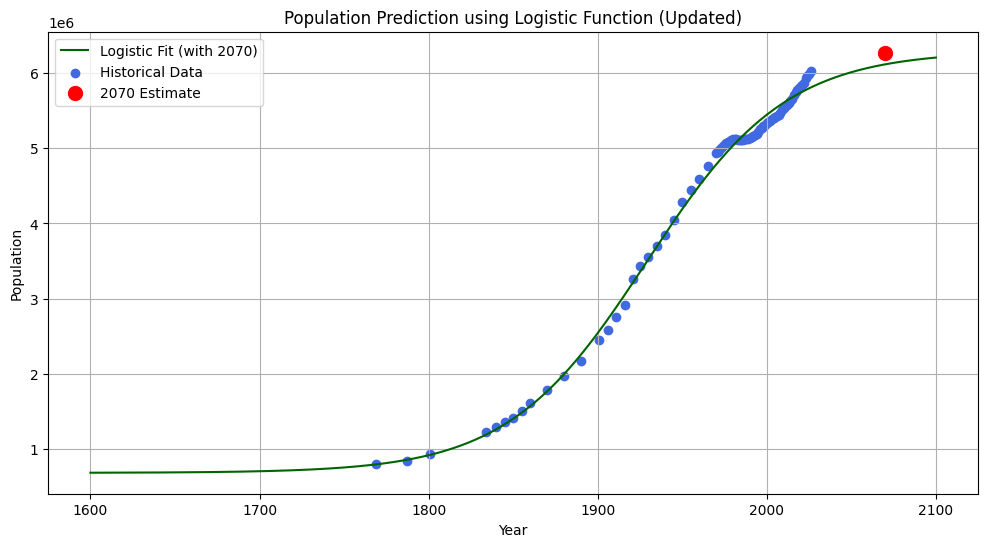

In [ ]:
plt.clf()

fig = plt.figure(figsize=(12, 6))

# Updated logistic curve
plt.plot(pred_inputs, pred_outputs_new,
         label='Logistic Fit (with 2070)',
         color='darkgreen')

# Original historical data
plt.scatter(inputs, output,
            label='Historical Data',
            color='royalblue')

# 2070 added point
plt.scatter(year_2070, pop_2070,
            label='2070 Estimate',
            color='red',
            s=100,
            zorder=5)

plt.title('Population Prediction using Logistic Function (Updated)')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ---- ORIGINAL FIT ----
popt_old, pcov_old = curve_fit(
    logistic,
    inputs,
    output,
    p0=[1930, 40, 7e5, 6e6]
)

pred_outputs_old = logistic(pred_inputs, *popt_old)


# ---- UPDATED FIT (with 2070 point) ----
year_2070 = 2070
pop_2070 = 6271185  # <-- replace with your actual estimate

new_inputs = np.append(inputs, year_2070)
new_output = np.append(output, pop_2070)

popt_new, pcov_new = curve_fit(
    logistic,
    new_inputs,
    new_output,
    p0=[1930, 40, 7e5, 6e6]
)

pred_outputs_new = logistic(pred_inputs, *popt_new)

<Figure size 640x480 with 0 Axes>

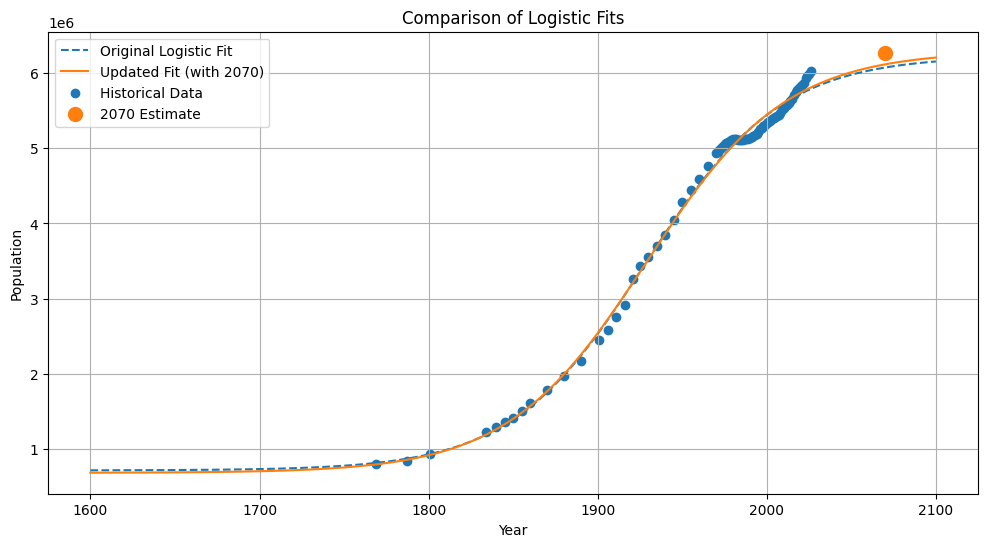

In [ ]:
plt.clf()
fig = plt.figure(figsize=(12, 6))

# Original curve
plt.plot(pred_inputs, pred_outputs_old,
         label='Original Logistic Fit',
         linestyle='--')

# Updated curve
plt.plot(pred_inputs, pred_outputs_new,
         label='Updated Fit (with 2070)')

# Historical data
plt.scatter(inputs, output,
            label='Historical Data')

# 2070 point
plt.scatter(year_2070, pop_2070,
            label='2070 Estimate',
            s=100,
            zorder=5)

plt.title('Comparison of Logistic Fits')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()

### weighted version

Weighted fitted parameters: [1.93116903e+03 4.56636826e+01 5.64092335e+05 6.53801984e+06] (ti, tau, C0, C1)


<Figure size 640x480 with 0 Axes>

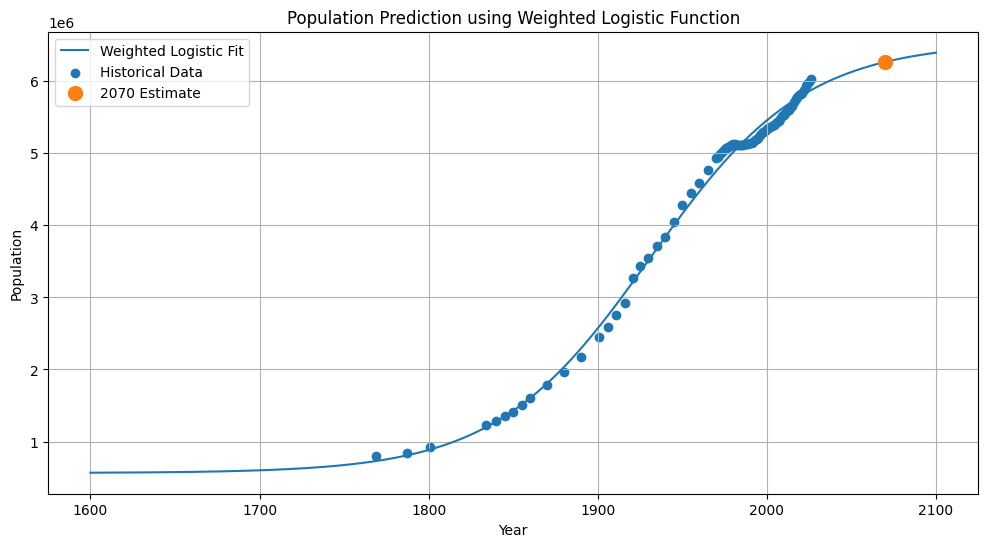

In [ ]:
# Extend dataset
new_inputs = np.append(inputs, year_2070)
new_output = np.append(output, pop_2070)

# Weighting: smaller sigma → stronger influence
sigma = np.ones_like(new_output)
sigma[-1] = 0.1

popt_weighted, pcov_weighted = curve_fit(
    logistic,
    new_inputs,
    new_output,
    p0=[1930, 40, 7e5, 6e6],
    sigma=sigma
)

pred_outputs_weighted = logistic(pred_inputs, *popt_weighted)

print(f'Weighted fitted parameters: {popt_weighted} (ti, tau, C0, C1)')


plt.clf()
fig = plt.figure(figsize=(12, 6))

# Weighted logistic curve
plt.plot(pred_inputs, pred_outputs_weighted,
         label='Weighted Logistic Fit')

# Historical data
plt.scatter(inputs, output,
            label='Historical Data')

# 2070 estimate point
plt.scatter(year_2070, pop_2070,
            label='2070 Estimate',
            s=100,
            zorder=5)

plt.title('Population Prediction using Weighted Logistic Function')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()

# Population with full statistikbanken regression for 2026-2100

In [26]:
sts_future = pd.read_excel("befolkningsfremskriving_til_2070.xlsx", skiprows=3)


#rename columns
sts_future.columns = ['Year', 'Population']

sts_future.head()

sts_future_array = sts_future.to_numpy()

combined_population_array = np.concatenate((population_array, sts_future_array), axis=0)

print(combined_population_array)

[[1.769000e+03 7.975840e+05]
 [1.787000e+03 8.418060e+05]
 [1.801000e+03 9.290010e+05]
 [1.834000e+03 1.230964e+06]
 [1.840000e+03 1.289075e+06]
 [1.845000e+03 1.356877e+06]
 [1.850000e+03 1.414648e+06]
 [1.855000e+03 1.507222e+06]
 [1.860000e+03 1.608362e+06]
 [1.870000e+03 1.784741e+06]
 [1.880000e+03 1.969039e+06]
 [1.890000e+03 2.172380e+06]
 [1.901000e+03 2.449540e+06]
 [1.906000e+03 2.588919e+06]
 [1.911000e+03 2.757076e+06]
 [1.916000e+03 2.921362e+06]
 [1.921000e+03 3.267831e+06]
 [1.925000e+03 3.434555e+06]
 [1.930000e+03 3.550656e+06]
 [1.935000e+03 3.706349e+06]
 [1.940000e+03 3.844312e+06]
 [1.945000e+03 4.045232e+06]
 [1.950000e+03 4.281275e+06]
 [1.955000e+03 4.448401e+06]
 [1.960000e+03 4.585256e+06]
 [1.965000e+03 4.767597e+06]
 [1.970000e+03 4.937579e+06]
 [1.971000e+03 4.950598e+06]
 [1.972000e+03 4.975653e+06]
 [1.973000e+03 5.007538e+06]
 [1.974000e+03 5.036184e+06]
 [1.975000e+03 5.054410e+06]
 [1.976000e+03 5.065313e+06]
 [1.977000e+03 5.079879e+06]
 [1.978000e+03

The optimal choice of parameters for the logistic function, given the sample data, is [1.93270789e+03 4.60589648e+01 5.68813063e+05 6.61271380e+06] (ti, tau, C0, C1).


<Figure size 640x480 with 0 Axes>

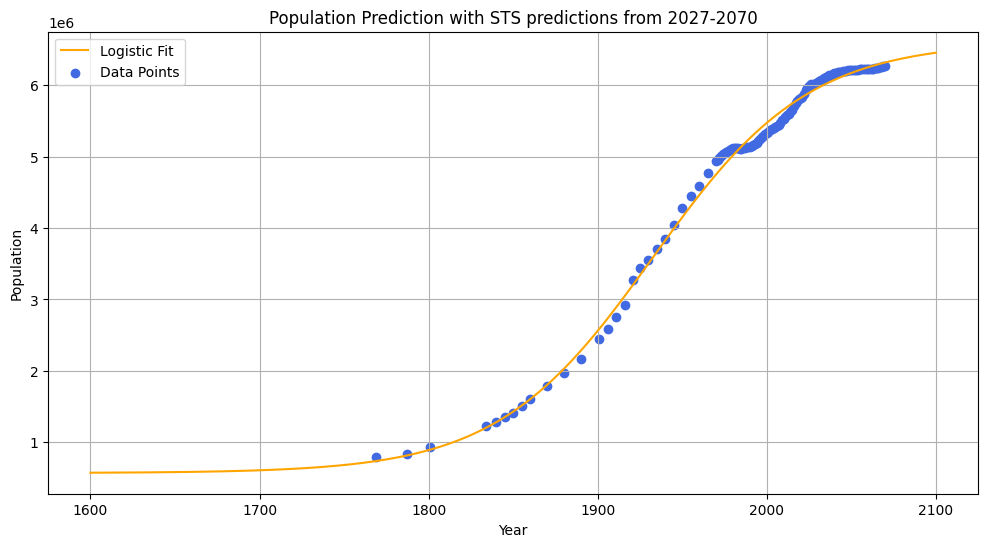

In [42]:
plt.clf()
new_inputs = combined_population_array[:, 0]  # years
new_output = combined_population_array[:, 1]  # population
pred_inputs = predictor_years

popt_new, pcov_new = curve_fit(logistic, new_inputs, new_output, p0=[1930, 40, 7e5, 6e6])
pred_outputs = logistic(pred_inputs, *popt_new)
print(f'The optimal choice of parameters for the logistic function, given the sample data, is {popt_new} (ti, tau, C0, C1).')

fig=plt.figure(figsize=(12, 6))
plt.plot(pred_inputs, pred_outputs, label='Logistic Fit', color='Orange')
plt.scatter(new_inputs, new_output, label='Data Points', color='RoyalBlue')
plt.title('Population Prediction with STS predictions from 2027-2070')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()


In [41]:
#Dataframe of pred_outputs
pred_outputs_df = pd.DataFrame({
    'Year': pred_inputs,
    'Predicted Population': pred_outputs
})

pred_outputs_df.to_excel("pop_regression_values_updated.xlsx", index=False)

## Cubic spline

perc_ncs = 65

limit_ncs = int(len(year) * perc_ncs / 100)
limit_pred_ncs = int(len(year) * (perc_ncs / 100) * 1.5)

reg_years_ncs = year[:limit_ncs]
reg_values_ncs = vpc[:limit_ncs]
reg_predictor_years_ncs = year[:limit_pred_ncs]

inputs_ncs_vpc = reg_years_ncs
outputs_ncs_vpc = reg_values_ncs
pred_inputs_ncs_vpc = reg_predictor_years_ncs

knots = [year[int(i*len(year)/9)] for i in range(1, 9)] 
ncs_model = ncs.get_natural_cubic_spline_model(
    inputs_ncs_vpc,
    outputs_ncs_vpc,
    minval=min(inputs_ncs_vpc),
    maxval=max(inputs_ncs_vpc),
    knots=knots
)

pred_outputs_vpc_ncs = ncs_model.predict(pred_inputs_ncs_vpc)

fig = plt.figure(figsize=(16, 8))

# Plot knots
for knot in knots:
    plt.axvline(knot, lw=0.5, color='darkgreen', alpha=0.4)

# Original data
plt.plot(year, vpc, 's', color='black', markersize=4,
         label='Original VPC data')

# Spline regression
plt.plot(pred_inputs_ncs_vpc, pred_outputs_vpc_ncs, color='crimson', lw=3,
         label='Natural cubic spline fit')

plt.legend(loc='best')
plt.xlabel('Year')
plt.ylabel('VPC')
plt.title('VPC – Natural Cubic Spline Regression')
plt.grid(alpha=0.3)
plt.show()